In [ ]:
# STEP 1 — Install + Import Libraries
!pip install -q kagglehub

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)



In [ ]:
# STEP 2 — Download Dataset
import kagglehub

path = kagglehub.dataset_download(
    "iarunava/cell-images-for-detecting-malaria"
)

print(path)



100%|██████████| 675M/675M [00:07<00:00, 91.2MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/iarunava/cell-images-for-detecting-malaria/versions/1


In [ ]:
# STEP 3 — Dataset Path
dataset_dir = os.path.join(
    path,
    "cell_images",
    "cell_images"
)

print(os.listdir(dataset_dir))



['Uninfected', 'Parasitized']


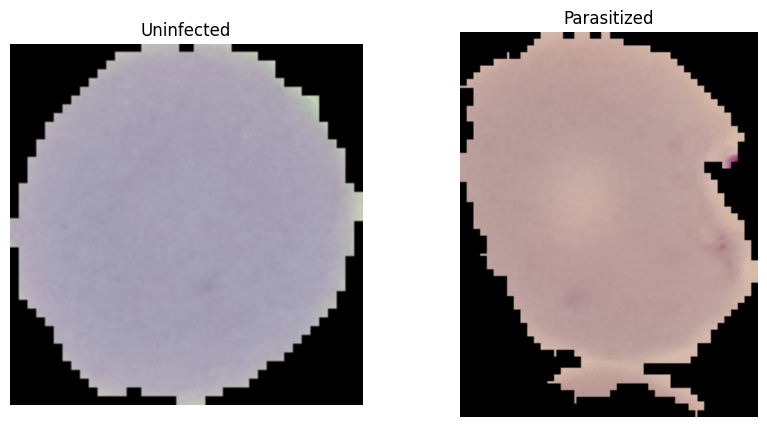

In [ ]:
# STEP 4 — Visualize Images
classes = ["Uninfected", "Parasitized"]

plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):

    sample_dir = os.path.join(dataset_dir, cls)

    sample_image = os.listdir(sample_dir)[0]

    img_path = os.path.join(sample_dir, sample_image)

    img = Image.open(img_path)

    plt.subplot(1,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis('off')

plt.show()

In [ ]:
# STEP 5 — Transform Images
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])



In [ ]:
# STEP 6 — Load Dataset
dataset = datasets.ImageFolder(
    root=dataset_dir,
    transform=transform
)

print(dataset.classes)
print(len(dataset))



['Parasitized', 'Uninfected']
27558


In [ ]:
# STEP 7 — Train/Test Split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, test_size]
)



In [ ]:
# STEP 8 — DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)



In [ ]:
# STEP 9 — CNN Architecture
class SimpleCNN(nn.Module):

    def __init__(self):

        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):

        x = self.conv_layers(x)
        x = self.fc_layers(x)

        return x



In [ ]:
# STEP 10 — Create Model
model = SimpleCNN()
print(model)



SimpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [ ]:
# STEP 11 — Loss + Optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)



In [ ]:
# STEP 12 — CNN Training Loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

num_epochs = 3

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )



Epoch [1/3], Loss: 0.4329
Epoch [2/3], Loss: 0.2045
Epoch [3/3], Loss: 0.1745


In [ ]:
# STEP 13 — Test Accuracy
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")



Test Accuracy: 93.40%


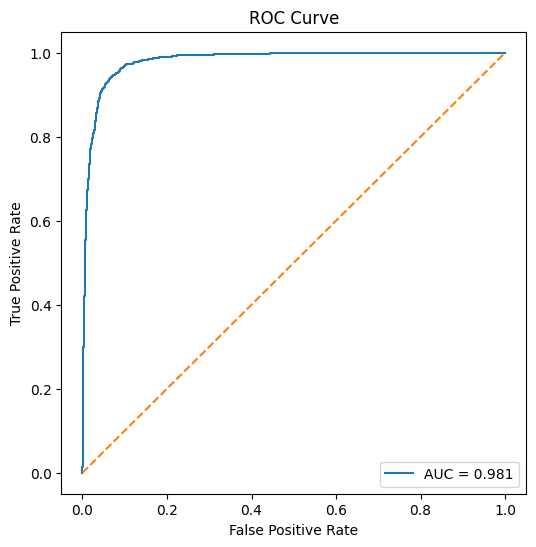

In [ ]:
# STEP 14 — ROC Curve
all_labels = []
all_probs = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        all_probs.extend(probs[:,1].cpu().numpy())

        all_labels.extend(labels.numpy())

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()



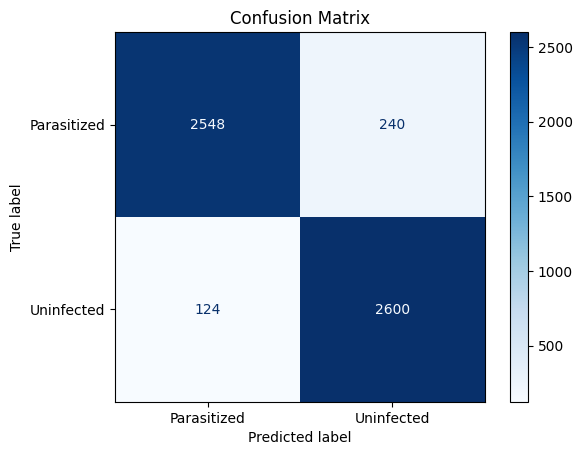

In [ ]:
# STEP 15 — Confusion Matrix
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())

        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)


disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()



In [ ]:
# STEP 16 — Save Model
torch.save(
    model.state_dict(),
    "cnn_model.pth"
)

print("Model saved successfully")



Model saved successfully


In [ ]:
# STEP 17 — Save Full Checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}, 'checkpoint.pth')

#COMPLETE END-TO-END PROJECT PIPELINE
#Project Notebook Name
#Phenotype_AI_Apoptosis_Classification_ML_CNN_ExplainableAI.ipynb
